Downloaded scene1.jpg
Downloaded scene2.jpg


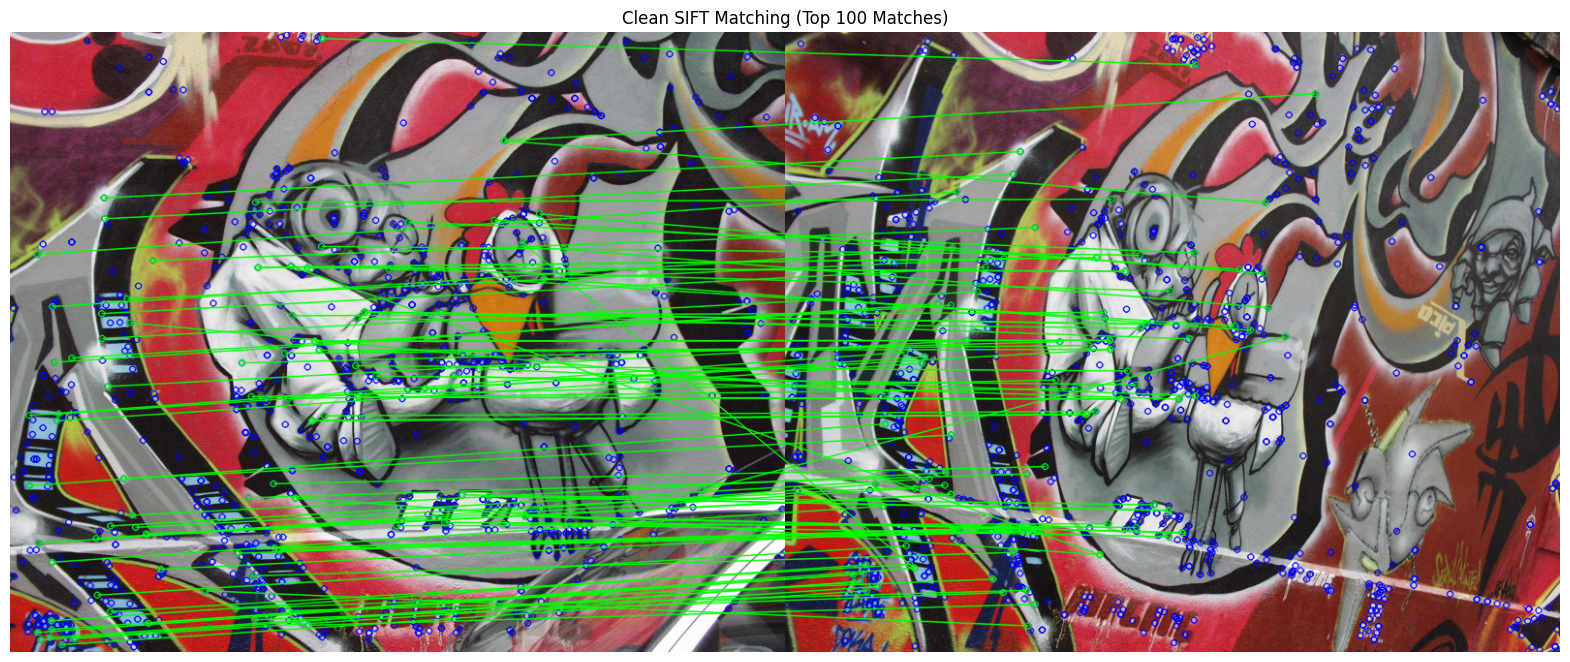

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests
import os

# 1. Download higher quality images
def download_file(url, filename):
    if not os.path.exists(filename):
        headers = {'User-Agent': 'Mozilla/5.0'}
        r = requests.get(url, headers=headers)
        with open(filename, 'wb') as f:
            f.write(r.content)
        print(f"Downloaded {filename}")

# Using a high-texture architectural pair
img1_url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/graf1.png"
img2_url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/graf3.png"

download_file(img1_url, "scene1.jpg")
download_file(img2_url, "scene2.jpg")

# 2. Load images
img1 = cv2.imread('scene1.jpg')
img2 = cv2.imread('scene2.jpg')

# Convert to grayscale for detection
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# 3. SIFT Detector
sift = cv2.SIFT_create(nfeatures=1000) # Limit features to keep it clean

# 4. Detect and Compute
kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

# 5. FLANN Matcher
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)
flann = cv2.FlannBasedMatcher(index_params, search_params)

matches = flann.knnMatch(des1, des2, k=2)

# 6. Lowe's Ratio Test (Tighter ratio for "cleaner" lines)
good_matches = []
for m, n in matches:
    if m.distance < 0.65 * n.distance:
        good_matches.append(m)

# 7. Visualize
# Sort matches by distance so the best ones are drawn on top
good_matches = sorted(good_matches, key=lambda x: x.distance)

draw_params = dict(matchColor=(0, 255, 0),       # Green lines for matches
                   singlePointColor=(255, 0, 0), # Red dots for keypoints
                   flags=cv2.DrawMatchesFlags_DEFAULT)

# Draw matches
result_img = cv2.drawMatches(img1, kp1, img2, kp2, good_matches[:100], None, **draw_params)

# IMPORTANT: Convert BGR (OpenCV) to RGB (Matplotlib)
# This prevents the "blue skin" or inverted color look
result_img_rgb = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)

# 8. Display
plt.figure(figsize=(20, 10))
plt.imshow(result_img_rgb)
plt.title(f"Clean SIFT Matching (Top 100 Matches)")
plt.axis('off')
plt.show()